<a href="https://colab.research.google.com/github/salwatiyas-cpu/Tugas-Machine-Learning/blob/main/Tugas_Project_Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Klasifikasi Tingkat Obesitas Menggunakan Metode XGBoost Berdasarkan Pola Konsumsi dan Aktivitas Fisik**

# **Dataset**

Data yang digunakan dalam penelitian ini merupakan dataset **Estimation of Obesity Levels Based on Eating Habits and Physical Condition** yang berisi informasi terkait kebiasaan makan, kondisi fisik, serta karakteristik individu dari negara Mexico, Peru, dan Colombia. Dataset ini digunakan untuk membangun model klasifikasi tingkat obesitas menggunakan metode Machine Learning berbasis XGBoost. Data tersebut berasal dari UC Irvine Machine Learning Repository dengan link: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

Dataset memiliki 2.111 records dan 17 atribut, yang terdiri dari 16 variabel independen (fitur/X) dan 1 variabel dependen (target/Y). Variabel independen mencakup karakteristik individu, riwayat keluarga, kebiasaan konsumsi makanan dan minuman, aktivitas fisik, penggunaan teknologi, konsumsi alkohol, serta moda transportasi yang digunakan. Sementara itu, variabel dependen berupa tingkat obesitas atau NObeyesdad / NObesity, yang terdiri dari beberapa kategori, yaitu:
* Insufficient Weight
* Normal Weight
* Overweight Level I
* Overweight Level II
* Obesity Type I
* Obesity Type II
* Obesity Type III

Dataset ini memiliki dua sumber pembentukan data, yaitu 77% data dihasilkan secara sintetis menggunakan aplikasi Weka dengan metode SMOTE filter, sedangkan 23% data dikumpulkan secara langsung dari pengguna melalui platform web. Dengan demikian, dataset ini memiliki jumlah data yang cukup memadai untuk digunakan dalam proses klasifikasi tingkat obesitas. Data terdiri atas berbagai jenis atribut, seperti:
* **Variabel kategorikal**, seperti jenis kelamin, riwayat keluarga dengan kelebihan berat badan, konsumsi makanan tinggi kalori, kebiasaan merokok, konsumsi alkohol, dan jenis transportasi.
* **Variabel numerik**, seperti usia, tinggi badan, berat badan, frekuensi konsumsi sayur, jumlah makan utama per hari, konsumsi air harian, frekuensi aktivitas fisik, serta waktu penggunaan perangkat teknologi.

Penelitian ini bertujuan untuk membangun model klasifikasi yang mampu memprediksi kategori tingkat obesitas individu berdasarkan pola makan dan kondisi fisik dengan menggunakan algoritma AdaBoost.

**Sumber Data:**

Palechor, Fabio Mendoza dan Manotas, Alexis De la. (2019). Estimation of Obesity Levels Based On Eating Habits and Physical Condition [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5H31Z

## **Variabel**

1. `Gender` = Jenis kelamin responden.
2. `Age` = Usia responden.
3. `Height` = Tinggi badan responden.
4. `Weight` = Berat badan responden.
5. `family_history_with_overweight` = Riwayat anggota keluarga yang mengalami atau pernah mengalami kelebihan berat badan.
6. `FAVC` = Kebiasaan mengonsumsi makanan tinggi kalori secara sering.
7. `FCVC` = Frekuensi konsumsi sayuran dalam makanan.
8. `NCP` = Jumlah makan utama yang dikonsumsi responden per hari.
9. `CAEC` = Kebiasaan mengonsumsi makanan di antara waktu makan utama.
10. `SMOKE` = Status kebiasaan merokok responden.
11. `CH2O` = Jumlah konsumsi air harian responden.
12. `SCC` = Kebiasaan memantau jumlah kalori yang dikonsumsi setiap hari.
13. `FAF` = Frekuensi aktivitas fisik responden.
14. `TUE` = Lama waktu penggunaan perangkat teknologi seperti ponsel, video game, televisi, komputer, dan perangkat lainnya.
15. `CALC` = Frekuensi konsumsi alkohol.
16. `MTRANS` = Moda transportasi yang biasanya digunakan responden.
17. `NObeyesdad` = Kategori tingkat obesitas responden sebagai **variabel target**.

## **Input Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = 'https://drive.google.com/uc?id=1G8UekmoM9Xr5RMVlf3uxfR3latjv4OCQ'
df = pd.read_csv(url)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.shape

(2111, 17)

Terdapat 2111 baris dan 17 kolom.

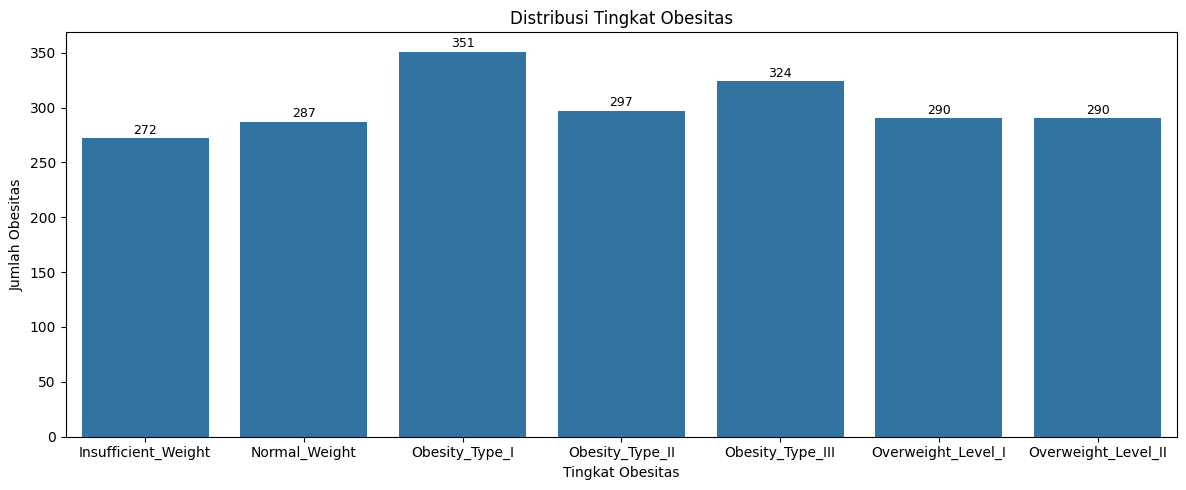

In [4]:
plt.figure(figsize=(12, 5))

ax = sns.countplot(
    data=df,
    x='NObeyesdad',
    order=sorted(df['NObeyesdad'].unique())
)

# Tambahkan jumlah data di atas batang
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=1.1)

plt.title('Distribusi Tingkat Obesitas')
plt.xlabel('Tingkat Obesitas')
plt.ylabel('Jumlah Obesitas')
plt.tight_layout()
plt.show()

# **Data Cleaning**

In [5]:
df_clean = df.copy()

## Missing Value

In [6]:
#cek missing value
df_clean.isna().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [7]:
df_clean.isna().sum()[df_clean.isna().sum() > 0]

,0


Tidak ada missing value

## Unique Value

In [8]:
for col in df.columns:
  print(df[col].value_counts())
  print('\n')

Gender
Male      1068
Female    1043
Name: count, dtype: int64


Age
18.000000    128
26.000000    101
21.000000     96
23.000000     89
19.000000     59
            ... 
50.832559      1
19.671876      1
18.951144      1
18.863875      1
36.310292      1
Name: count, Length: 1402, dtype: int64


Height
1.700000    60
1.650000    50
1.600000    43
1.750000    39
1.620000    36
            ..
1.720379     1
1.745528     1
1.699474     1
1.621048     1
1.843172     1
Name: count, Length: 1574, dtype: int64


Weight
80.000000    59
70.000000    43
50.000000    42
75.000000    40
60.000000    37
             ..
80.386078     1
68.850970     1
86.319887     1
88.037480     1
65.912688     1
Name: count, Length: 1525, dtype: int64


family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64


FAVC
yes    1866
no      245
Name: count, dtype: int64


FCVC
3.000000    652
2.000000    600
1.000000     33
2.971574      2
2.630137      2
           ... 
2.886260      1
2.6581

Berdasarkan hasil identifikasi unique value, tidak ditemukan unique value.

## Data Duplicate

In [9]:
df_clean[df_clean.duplicated(keep=False)]

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
105,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
145,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
208,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight


In [10]:
duplikat = df_clean[df_clean.duplicated(keep=False)].sort_values(by=df_clean.columns.tolist())
duplikat

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
295,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
282,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
523,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
527,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
659,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
663,Female,21.0,1.52,42.0,no,yes,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight


In [11]:
print("Jumlah baris duplikat:", len(duplikat))

Jumlah baris duplikat: 33


Terdapat 33 data duplikat

In [12]:
df_dup = df_clean.drop_duplicates()
df_clean = df_dup.copy()

## Data Type

In [13]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   object 
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   object 
 5   FAVC                            2087 non-null   object 
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   object 
 9   SMOKE                           2087 non-null   object 
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   object 
 12  FAF                             2087 no

## Deteksi Outlier

In [14]:
check_cols = df_clean[['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF']]

Q1 = check_cols.quantile(0.25)
Q3 = check_cols.quantile(0.75)
IQR = Q3 - Q1

outliers = (
    (check_cols < (Q1 - 1.5 * IQR)) |
    (check_cols > (Q3 + 1.5 * IQR))
)

outliers.sum()

,0
Age,167
Height,1
Weight,1
NCP,577
CH2O,0
FAF,0


In [15]:
numeric_cols = ['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF']

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_data = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    print(f"\nVariabel: {col}")
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Jumlah outlier:", len(outlier_data))
    print("Nilai minimum outlier:", outlier_data[col].min())
    print("Nilai maksimum outlier:", outlier_data[col].max())


Variabel: Age
Lower bound: 10.789843749999996
Upper bound: 35.12609375
Jumlah outlier: 167
Nilai minimum outlier: 35.194089
Nilai maksimum outlier: 61.0

Variabel: Height
Lower bound: 1.421209
Upper bound: 1.978461
Jumlah outlier: 1
Nilai minimum outlier: 1.98
Nilai maksimum outlier: 1.98

Variabel: Weight
Lower bound: 2.976139500000002
Upper bound: 171.03976749999998
Jumlah outlier: 1
Nilai minimum outlier: 173.0
Nilai maksimum outlier: 173.0

Variabel: NCP
Lower bound: 2.2436675
Upper bound: 3.4537994999999997
Jumlah outlier: 577
Nilai minimum outlier: 1.0
Nilai maksimum outlier: 4.0

Variabel: CH2O
Lower bound: 0.2780150000000001
Upper bound: 3.779099
Jumlah outlier: 0
Nilai minimum outlier: nan
Nilai maksimum outlier: nan

Variabel: FAF
Lower bound: -2.2058904999999998
Upper bound: 4.0084975
Jumlah outlier: 0
Nilai minimum outlier: nan
Nilai maksimum outlier: nan


## Encode categorical variable

In [16]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
df_clean

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,2,0,2.000000,0,0.000000,1.000000,3,3,1
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,2,1,3.000000,1,3.000000,0.000000,2,3,1
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,2,0,2.000000,0,2.000000,1.000000,1,3,1
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,2,0,2.000000,0,2.000000,0.000000,1,4,5
4,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,2,0,2.000000,0,0.000000,0.000000,2,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,2,0,1.728139,0,1.676269,0.906247,2,3,4
2107,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,2,0,2.005130,0,1.341390,0.599270,2,3,4
2108,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,2,0,2.054193,0,1.414209,0.646288,2,3,4
2109,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,2,0,2.852339,0,1.139107,0.586035,2,3,4


## Hasil Akhir

In [17]:
# Reset Index
df_clean.reset_index(drop=True, inplace=True)

In [18]:
print(f"\nSetelah Data Cleaning: {df_clean.shape}")


Setelah Data Cleaning: (2087, 17)


Data yang awalnya memiliki total 1994 berubah menjadi 1993 data. Awalnya memiliki 128 variabel berubah menjadi 101 variabel.

In [19]:
praproses_summary = pd.DataFrame({
    'Tahap': [
        'Dataset awal',
        'Hapus baris duplikat'
    ],
    'Jumlah Baris': [
        df.shape[0],
        df_clean.shape[0]
    ],
    'Jumlah Kolom': [
        df.shape[1],
        df_clean.shape[1]
    ]
})

print("\n" + "="*50)
print("TABEL RINGKASAN PRA-PROSES")
print("="*50)
print(praproses_summary.to_string(index=False))

print(f"\nTotal variabel prediktor akhir: {df_clean.shape[1]-1}")


TABEL RINGKASAN PRA-PROSES
               Tahap  Jumlah Baris  Jumlah Kolom
        Dataset awal          2111            17
Hapus baris duplikat          2087            17

Total variabel prediktor akhir: 16


# **Eksplorasi Data**

In [20]:
df_eks = df_clean.copy()

In [21]:
df_eks.describe()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,0.504073,24.353090,1.702674,86.858730,0.825108,0.883565,2.421466,2.701179,1.853857,0.021083,2.004749,0.045999,1.012812,0.663035,2.270244,2.358888,3.014375
std,0.500103,6.368801,0.093186,26.190847,0.379966,0.320823,0.534737,0.764614,0.459494,0.143695,0.608284,0.209533,0.853475,0.608153,0.517008,1.265402,1.948470
min,0.000000,14.000000,1.450000,39.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,19.915937,1.630178,66.000000,1.000000,1.000000,2.000000,2.697467,2.000000,0.000000,1.590922,0.000000,0.124505,0.000000,2.000000,3.000000,1.000000
50%,1.000000,22.847618,1.701584,83.101100,1.000000,1.000000,2.396265,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,0.630866,2.000000,3.000000,3.000000
75%,1.000000,26.000000,1.769491,108.015907,1.000000,1.000000,3.000000,3.000000,2.000000,0.000000,2.466193,0.000000,1.678102,1.000000,3.000000,3.000000,5.000000
max,1.000000,61.000000,1.980000,173.000000,1.000000,1.000000,3.000000,4.000000,3.000000,1.000000,3.000000,1.000000,3.000000,2.000000,3.000000,4.000000,6.000000


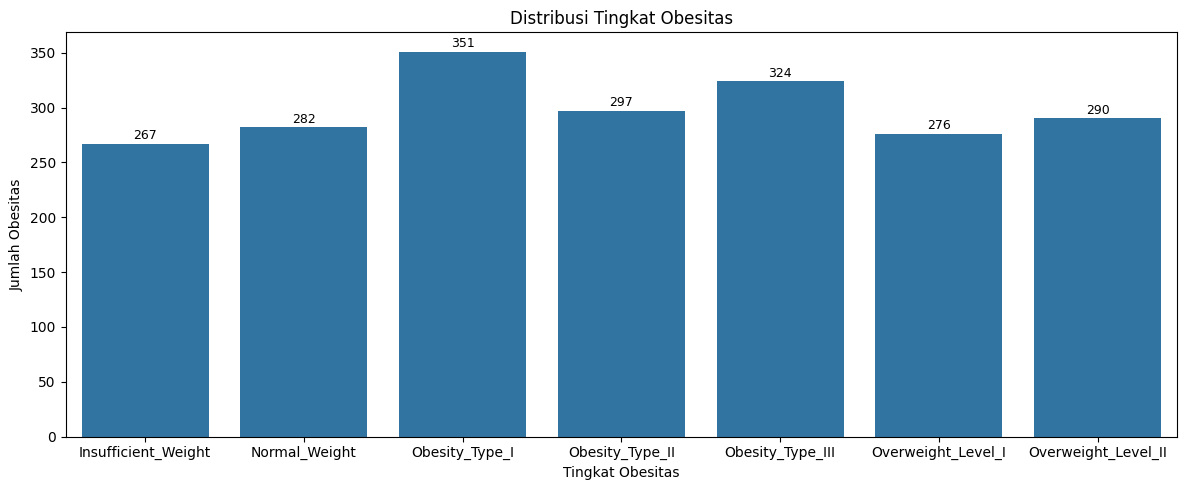

In [22]:
plt.figure(figsize=(12, 5))

ax = sns.countplot(
    data=df_dup,
    x='NObeyesdad',
    order=sorted(df_dup['NObeyesdad'].unique())
)

# Tambahkan jumlah data di atas batang
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=1.1)

plt.title('Distribusi Tingkat Obesitas')
plt.xlabel('Tingkat Obesitas')
plt.ylabel('Jumlah Obesitas')
plt.tight_layout()
plt.show()

In [23]:
categorical_cols = df_dup.select_dtypes(include=['object']).columns
df_dup[categorical_cols].describe().T

,count,unique,top,freq
Gender,2087,2,Male,1052
family_history_with_overweight,2087,2,yes,1722
FAVC,2087,2,yes,1844
CAEC,2087,4,Sometimes,1761
SMOKE,2087,2,no,2043
SCC,2087,2,no,1991
CALC,2087,4,Sometimes,1380
MTRANS,2087,5,Public_Transportation,1558
NObeyesdad,2087,7,Obesity_Type_I,351


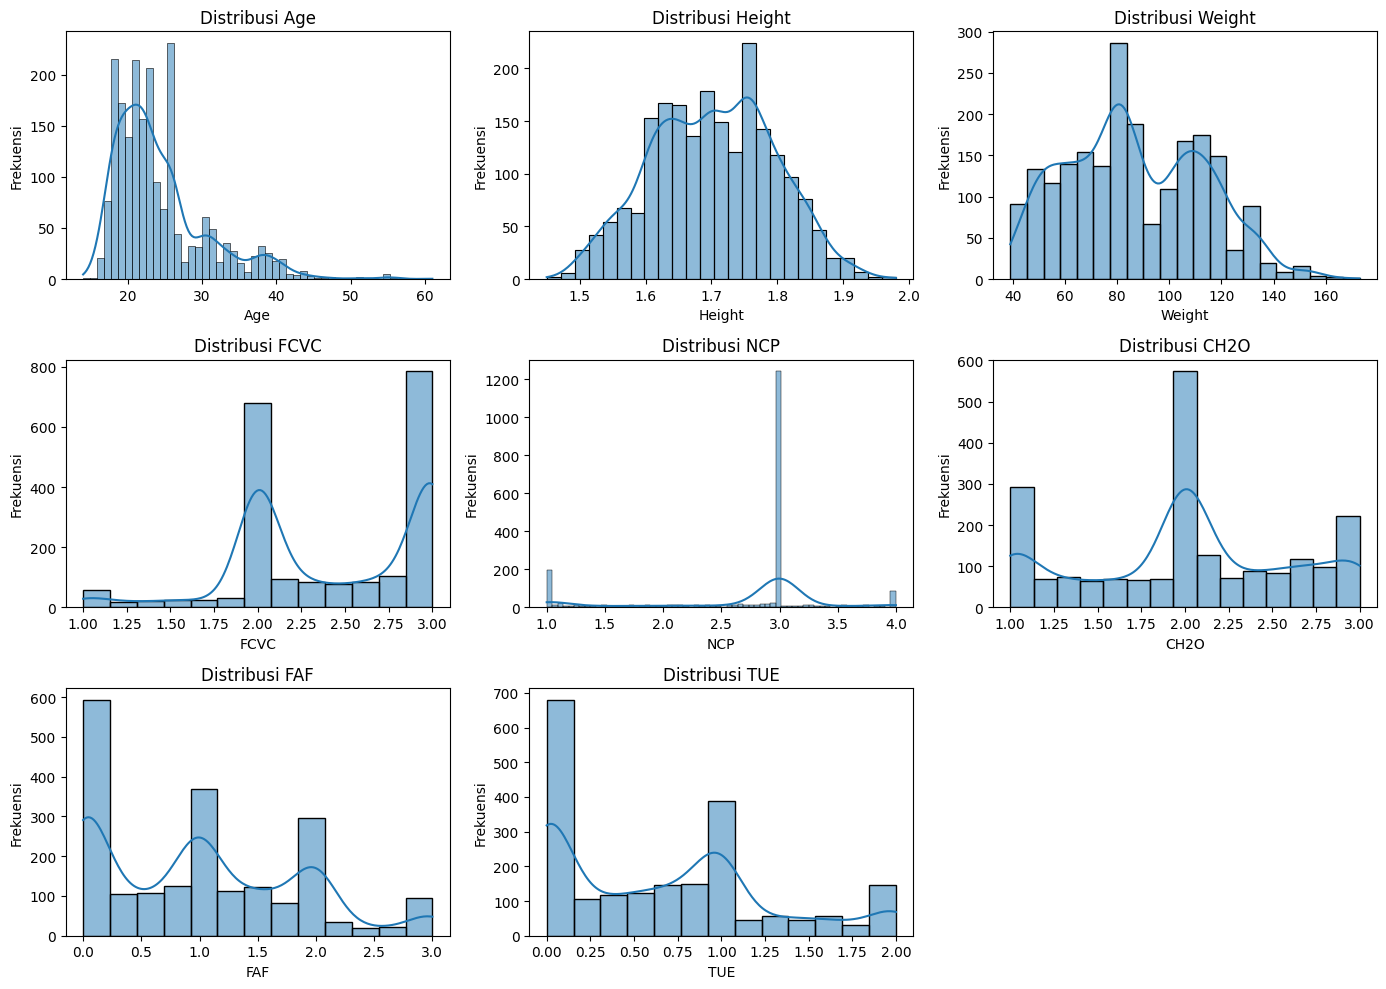

In [24]:
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

plt.figure(figsize=(14,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_dup[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

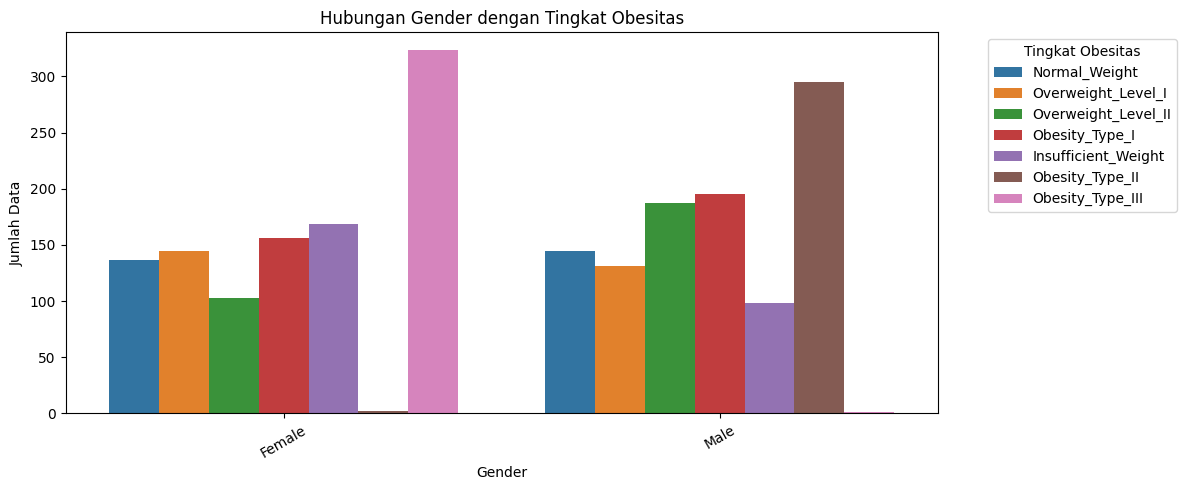

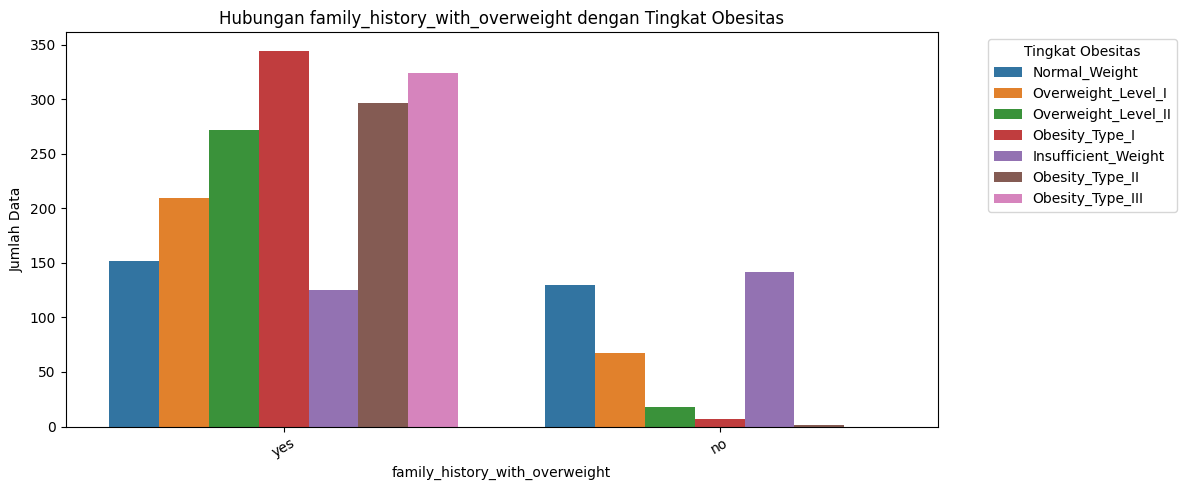

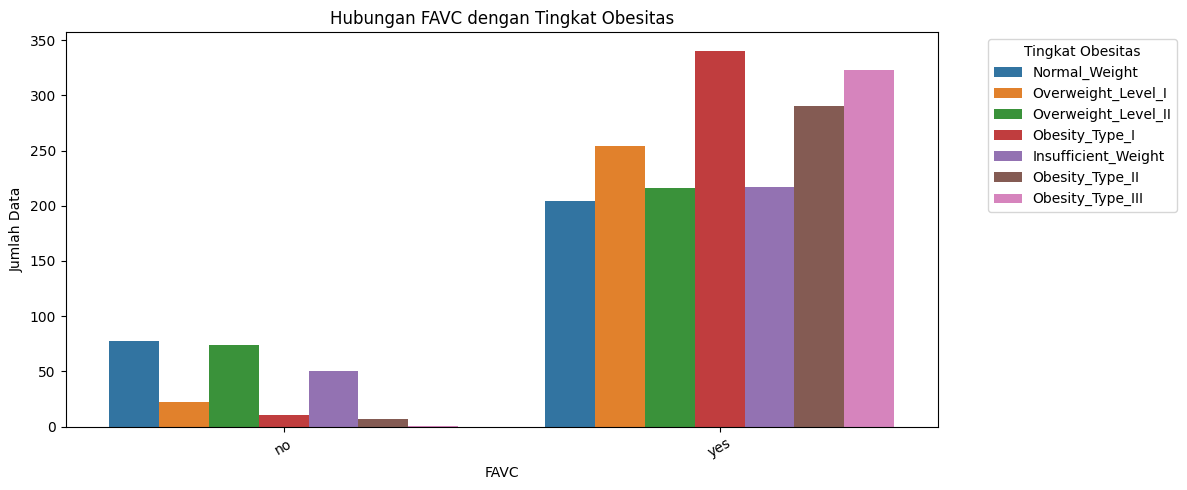

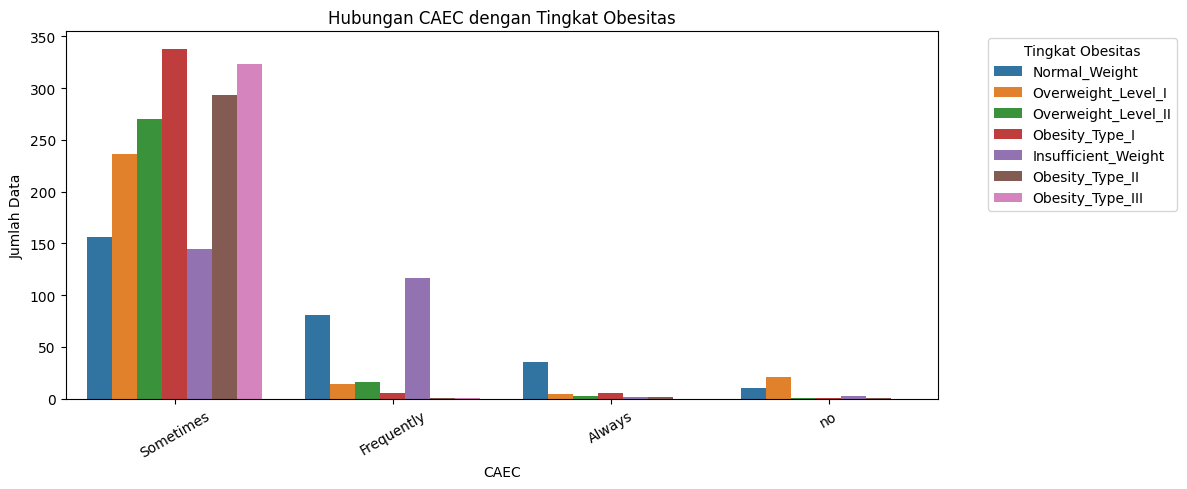

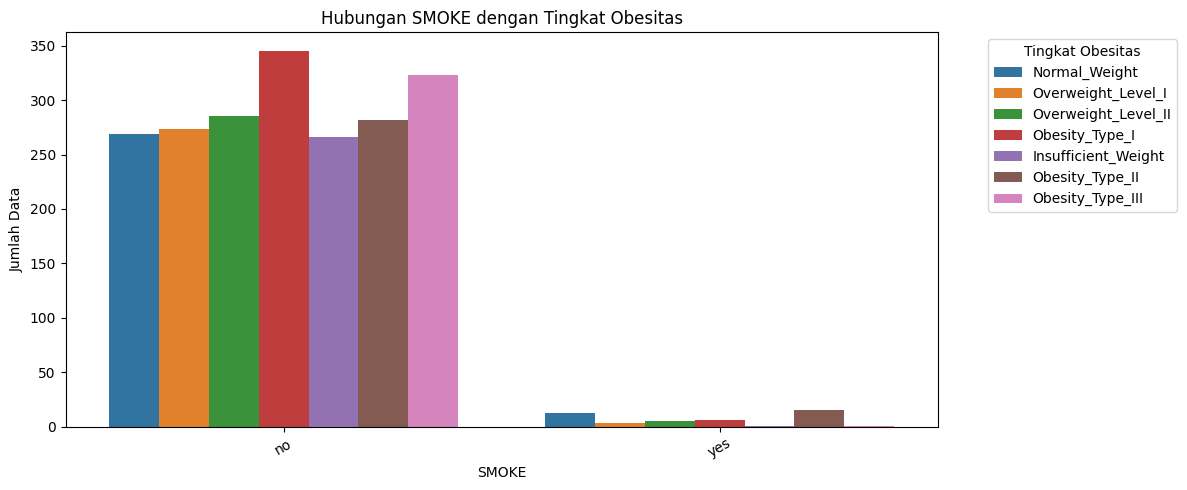

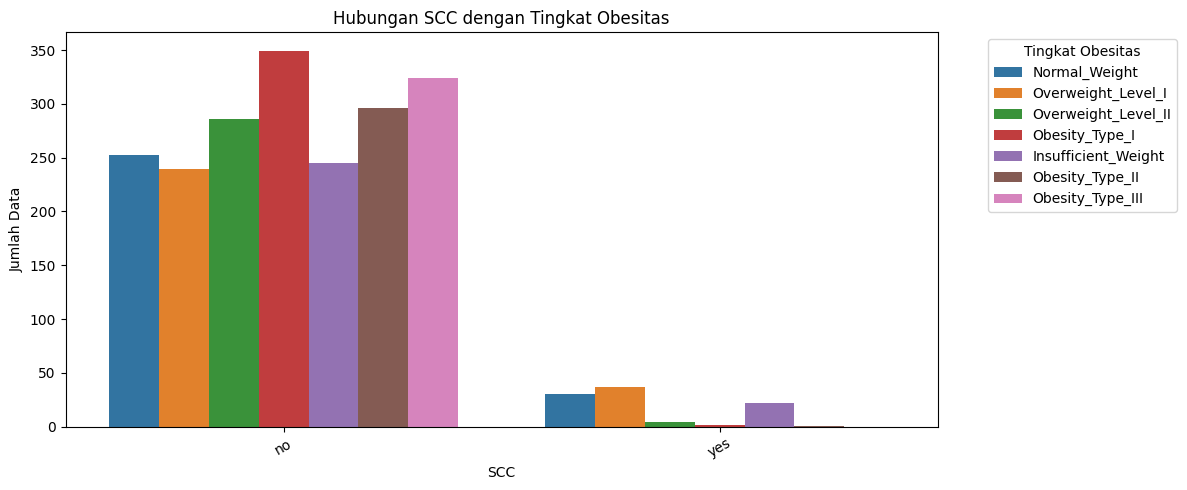

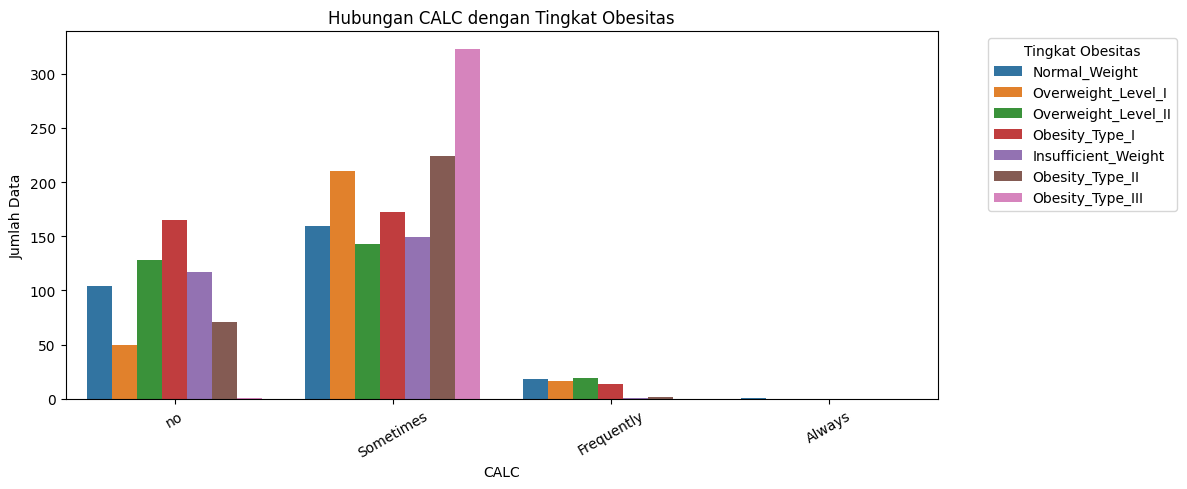

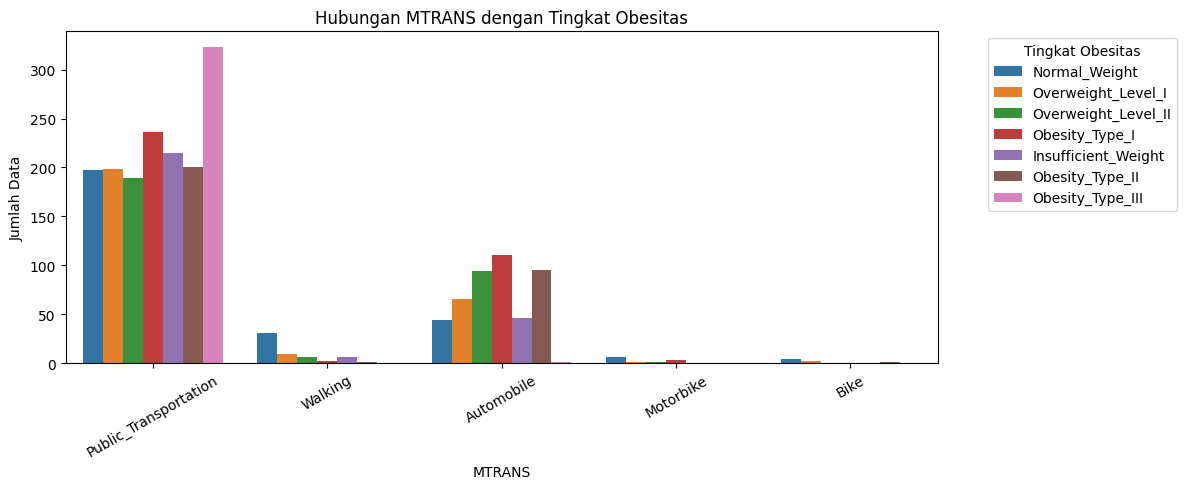

In [25]:
categorical_cols = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
]

for col in categorical_cols:
    plt.figure(figsize=(12,5))
    sns.countplot(data=df_dup, x=col, hue='NObeyesdad')
    plt.title(f'Hubungan {col} dengan Tingkat Obesitas')
    plt.xlabel(col)
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=30)
    plt.legend(title='Tingkat Obesitas', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

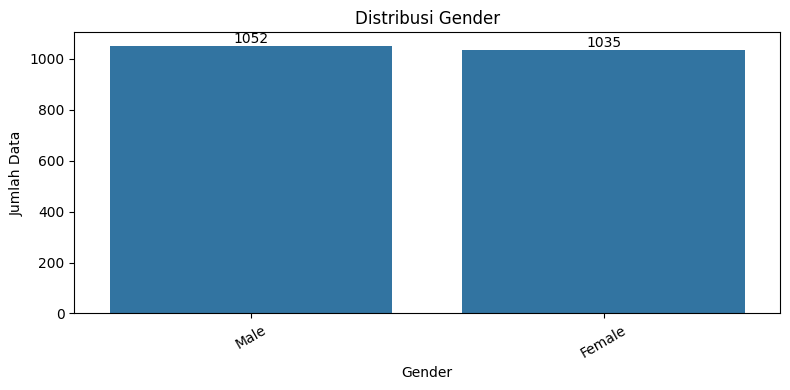

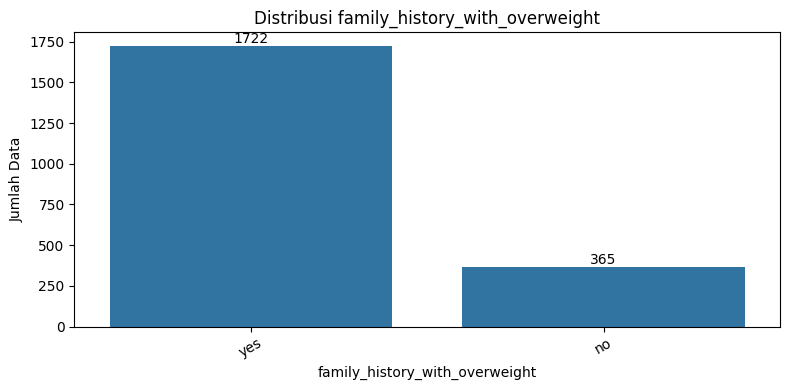

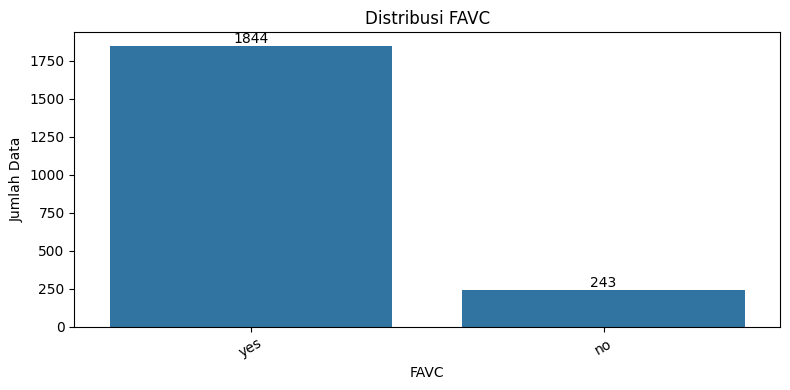

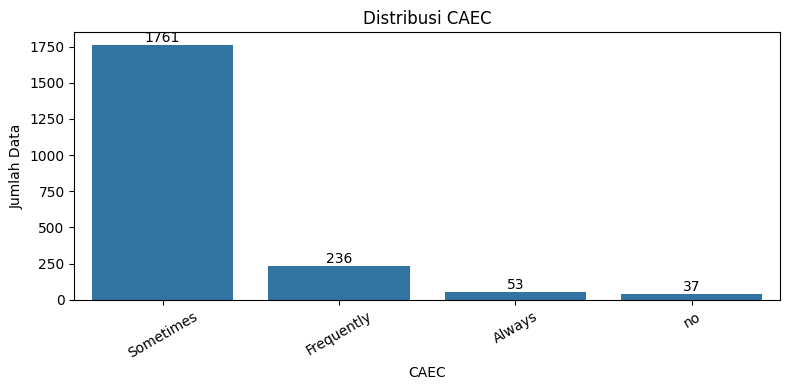

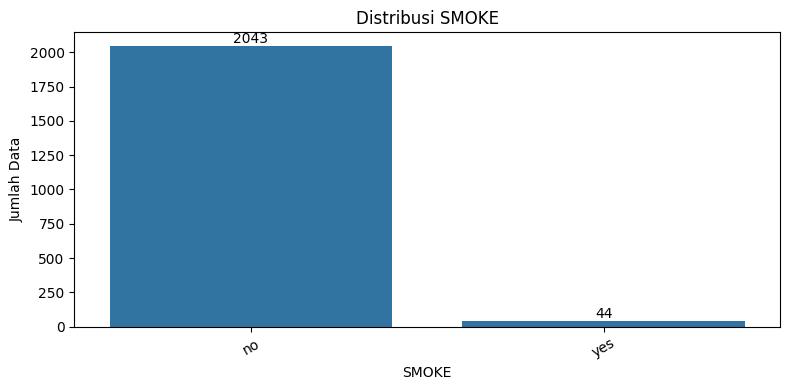

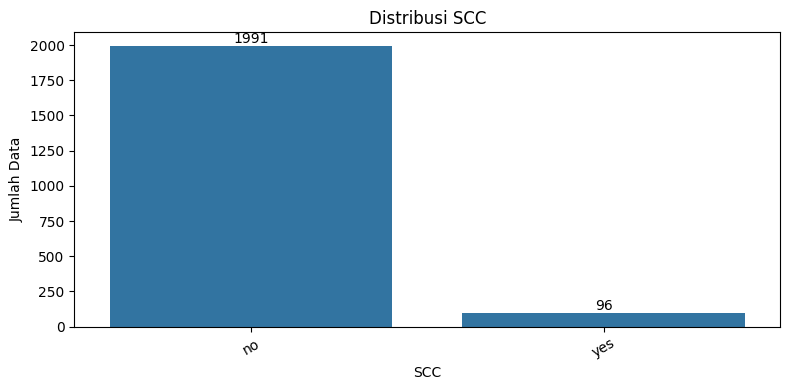

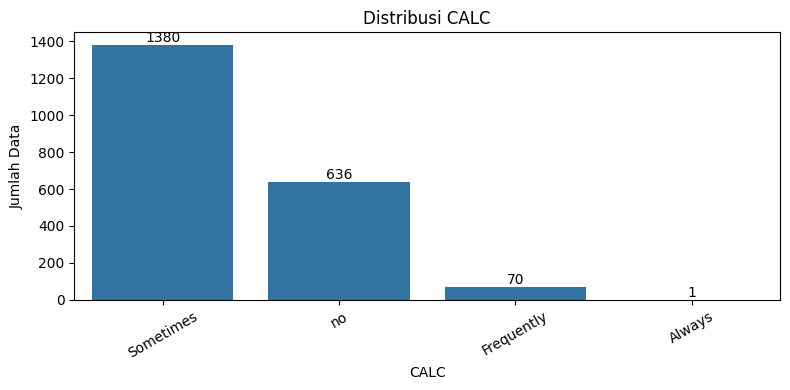

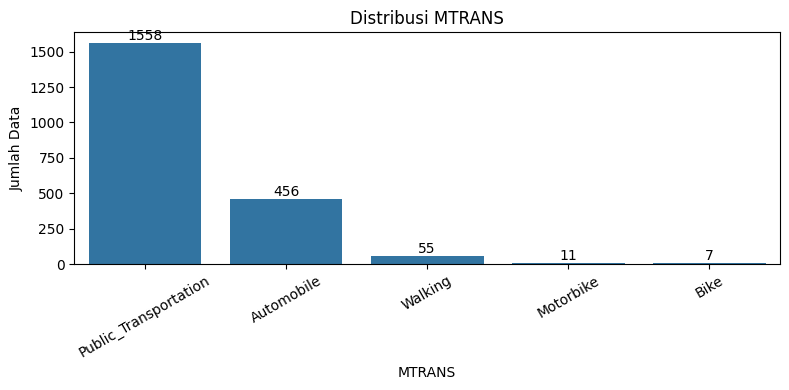

In [26]:
categorical_cols = [
    'Gender',
    'family_history_with_overweight',
    'FAVC',
    'CAEC',
    'SMOKE',
    'SCC',
    'CALC',
    'MTRANS'
]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    ax = sns.countplot(data=df_dup, x=col, order=df_dup[col].value_counts().index)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=30)

    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.show()

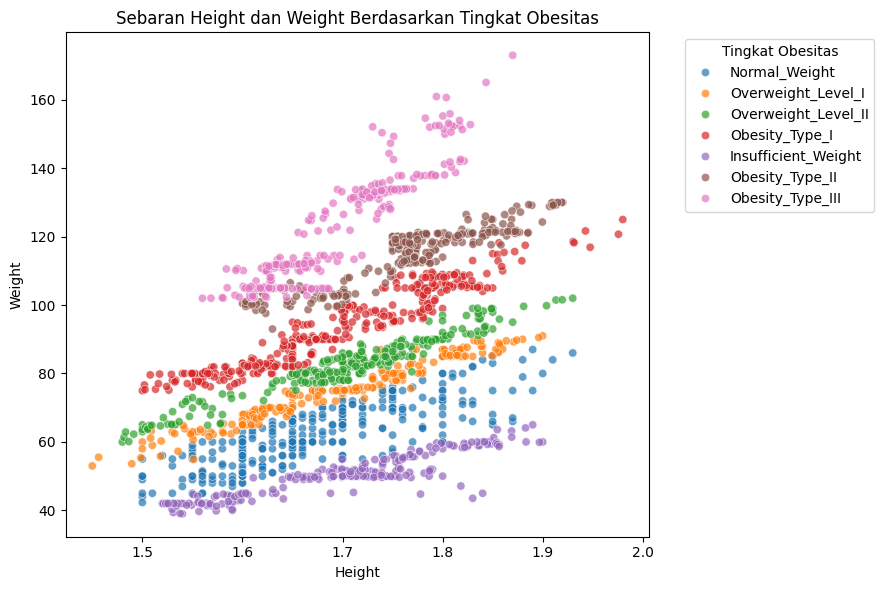

In [27]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df_dup,
    x='Height',
    y='Weight',
    hue='NObeyesdad',
    alpha=0.7
)

plt.title('Sebaran Height dan Weight Berdasarkan Tingkat Obesitas')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend(title='Tingkat Obesitas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **Pemodelan**

In [28]:
df_xgb = df_eks.copy()
df_xgb

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,2,0,2.000000,0,0.000000,1.000000,3,3,1
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,2,1,3.000000,1,3.000000,0.000000,2,3,1
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,2,0,2.000000,0,2.000000,1.000000,1,3,1
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,2,0,2.000000,0,2.000000,0.000000,1,4,5
4,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,2,0,2.000000,0,0.000000,0.000000,2,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,2,0,1.728139,0,1.676269,0.906247,2,3,4
2083,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,2,0,2.005130,0,1.341390,0.599270,2,3,4
2084,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,2,0,2.054193,0,1.414209,0.646288,2,3,4
2085,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,2,0,2.852339,0,1.139107,0.586035,2,3,4


## **Split Data & Standarisasi**

In [29]:
X = df_xgb.drop(columns=['NObeyesdad'])
y = df_xgb['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData Train: {X_train.shape}")
print(f"Data Test: {X_test.shape}")


Data Train: (1669, 16)
Data Test: (418, 16)


In [30]:
# Cek distribusi kelas target sebelum split
dist = pd.DataFrame({
    'Overall (%)': (y.value_counts(normalize=True) * 100).round(2),
    'Train (%)': (y_train.value_counts(normalize=True) * 100).round(2),
    'Test (%)': (y_test.value_counts(normalize=True) * 100).round(2)
})

dist

,Overall (%),Train (%),Test (%)
NObeyesdad,,,
2,16.82,16.84,16.75
4,15.52,15.52,15.55
3,14.23,14.20,14.35
6,13.90,13.90,13.88
1,13.51,13.48,13.64
5,13.22,13.24,13.16
0,12.79,12.82,12.68


In [31]:
pd.Series(y_test).value_counts().sort_index()

,count
NObeyesdad,
0,53
1,57
2,70
3,60
4,65
5,55
6,58


## **XGBoost**

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [58]:
# 1. Model XGBoost
xgb_model = XGBClassifier(
    objective='multi:softmax',
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    num_class=7,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=7, ...)

In [34]:
# 2. Prediksi
y_pred = xgb_model.predict(X_test)

In [59]:
# 3. Evaluasi Model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9760765550239234

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      0.95      0.96        57
           2       0.99      0.99      0.99        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.94      0.93      0.94        55
           6       0.95      0.98      0.97        58

    accuracy                           0.98       418
   macro avg       0.98      0.98      0.98       418
weighted avg       0.98      0.98      0.98       418



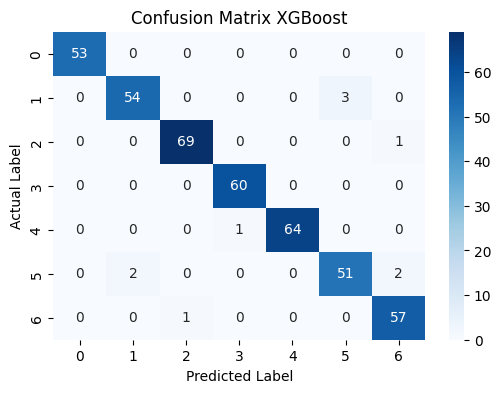

In [60]:
# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [61]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,FCVC,0.171174
0,Gender,0.151632
3,Weight,0.139569
14,CALC,0.080931
5,FAVC,0.079351
10,CH2O,0.052059
8,CAEC,0.048762
2,Height,0.048377
7,NCP,0.041903
4,family_history_with_overweight,0.039807


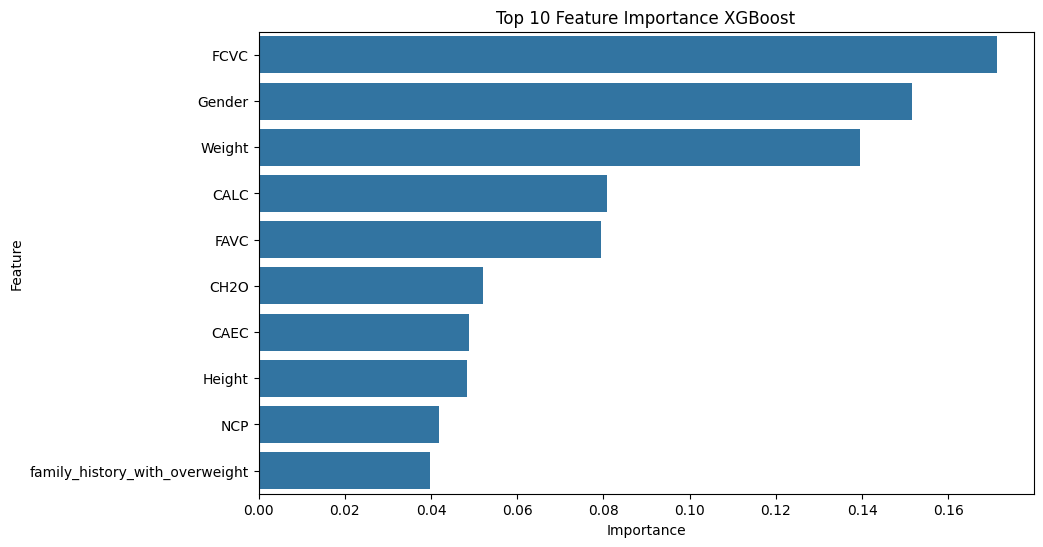

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

## **AdaBoost**

In [39]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [40]:
# 1. Model AdaBoost
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=100, random_state=42)

In [41]:
# 2. Prediksi
y_pred_ada = ada_model.predict(X_test)
pd.Series(y_pred_ada).value_counts().sort_index()

,count
0,43
1,66
2,36
3,140
5,36
6,97


In [42]:
# 3. Evaluasi Model
accuracy_ada = accuracy_score(y_test, y_pred_ada)

print("Accuracy AdaBoost:", accuracy_ada)
print("\nClassification Report AdaBoost:")
print(classification_report(y_test, y_pred_ada))

Accuracy AdaBoost: 0.46172248803827753

Classification Report AdaBoost:
              precision    recall  f1-score   support

           0       0.60      0.49      0.54        53
           1       0.39      0.46      0.42        57
           2       0.58      0.30      0.40        70
           3       0.41      0.97      0.58        60
           4       0.00      0.00      0.00        65
           5       0.61      0.40      0.48        55
           6       0.41      0.69      0.52        58

    accuracy                           0.46       418
   macro avg       0.43      0.47      0.42       418
weighted avg       0.43      0.46      0.41       418



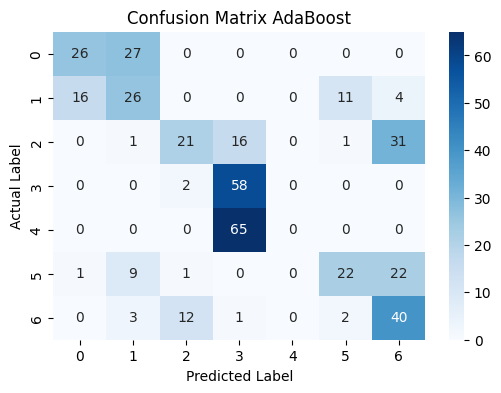

In [43]:
# 4. Confusion matrix
cm_ada = confusion_matrix(y_test, y_pred_ada)

plt.figure(figsize=(6,4))
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix AdaBoost')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [44]:
feature_importance_ada = pd.DataFrame({
    'Feature': X.columns,
    'Importance': ada_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance_ada.head(10)

,Feature,Importance
3,Weight,0.989257
8,CAEC,0.010743
1,Age,0.000000
0,Gender,0.000000
4,family_history_with_overweight,0.000000
5,FAVC,0.000000
6,FCVC,0.000000
2,Height,0.000000
7,NCP,0.000000
9,SMOKE,0.000000


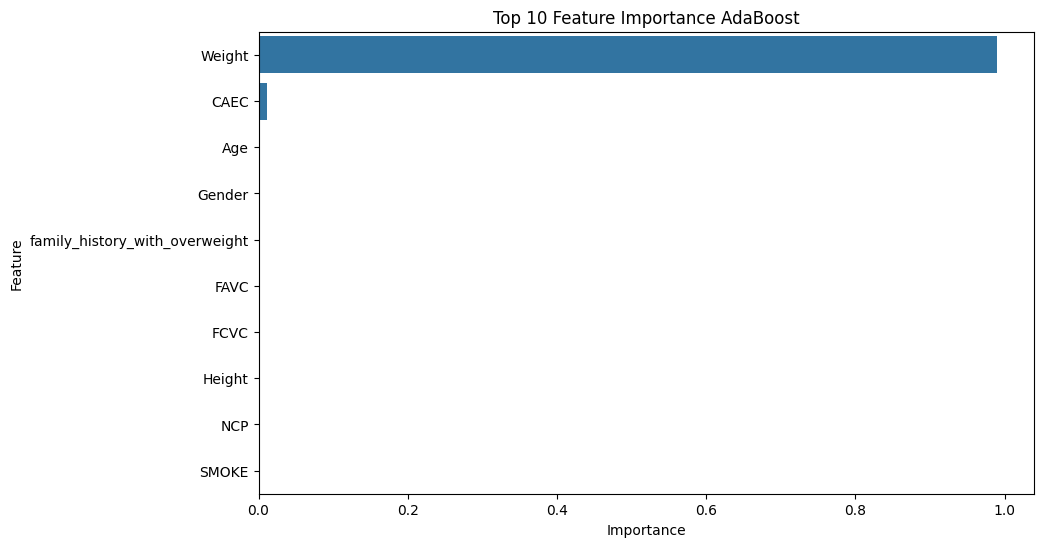

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_ada.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance AdaBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

## **Decision Tree**

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Model Decision Tree
# =========================
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

# =========================
# Prediksi
# =========================
y_pred_dt = dt_model.predict(X_test)

# =========================
# Evaluasi
# =========================
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy Decision Tree:", accuracy_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy Decision Tree: 0.9258373205741627

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        53
           1       0.83      0.86      0.84        57
           2       0.94      0.94      0.94        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.83      0.80      0.81        55
           6       0.90      0.97      0.93        58

    accuracy                           0.93       418
   macro avg       0.92      0.92      0.92       418
weighted avg       0.93      0.93      0.93       418



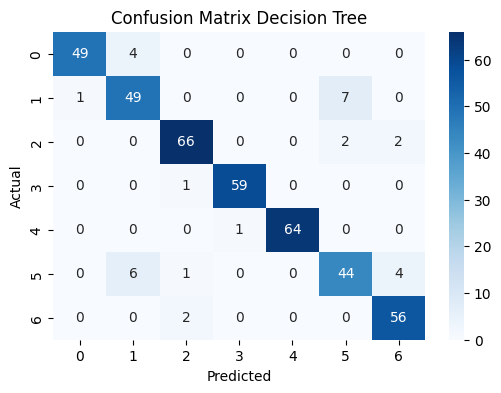

In [47]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [48]:
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance_dt = feature_importance_dt.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_dt.head(10)

,Feature,Importance
3,Weight,0.447376
2,Height,0.229284
0,Gender,0.159879
1,Age,0.044553
14,CALC,0.026171
6,FCVC,0.025551
5,FAVC,0.021480
8,CAEC,0.015732
7,NCP,0.007610
13,TUE,0.005480


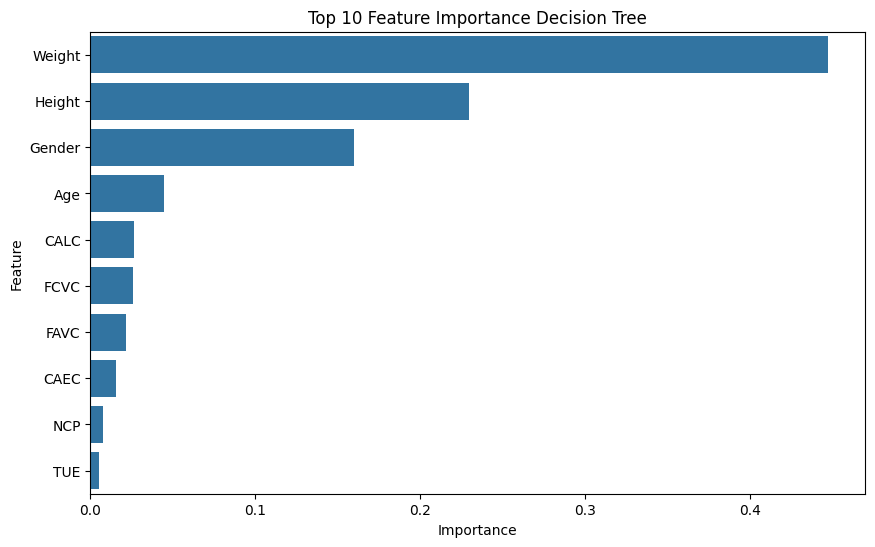

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_dt.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance Decision Tree')

plt.show()

## **Random Forest**

In [50]:
from sklearn.ensemble import RandomForestClassifier

# =========================
# Model Random Forest
# =========================
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# =========================
# Prediksi
# =========================
y_pred_rf = rf_model.predict(X_test)

# =========================
# Evaluasi
# =========================
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.9545454545454546

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        53
           1       0.84      0.95      0.89        57
           2       1.00      0.97      0.99        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.89      0.91      0.90        55
           6       0.96      0.91      0.94        58

    accuracy                           0.95       418
   macro avg       0.95      0.95      0.95       418
weighted avg       0.96      0.95      0.96       418



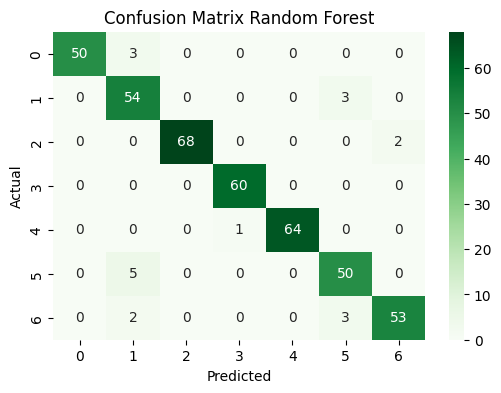

In [51]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [52]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rf.head(10)

,Feature,Importance
3,Weight,0.350239
2,Height,0.098249
1,Age,0.095315
6,FCVC,0.093584
0,Gender,0.053124
7,NCP,0.049595
13,TUE,0.045409
12,FAF,0.043256
10,CH2O,0.039917
4,family_history_with_overweight,0.029645


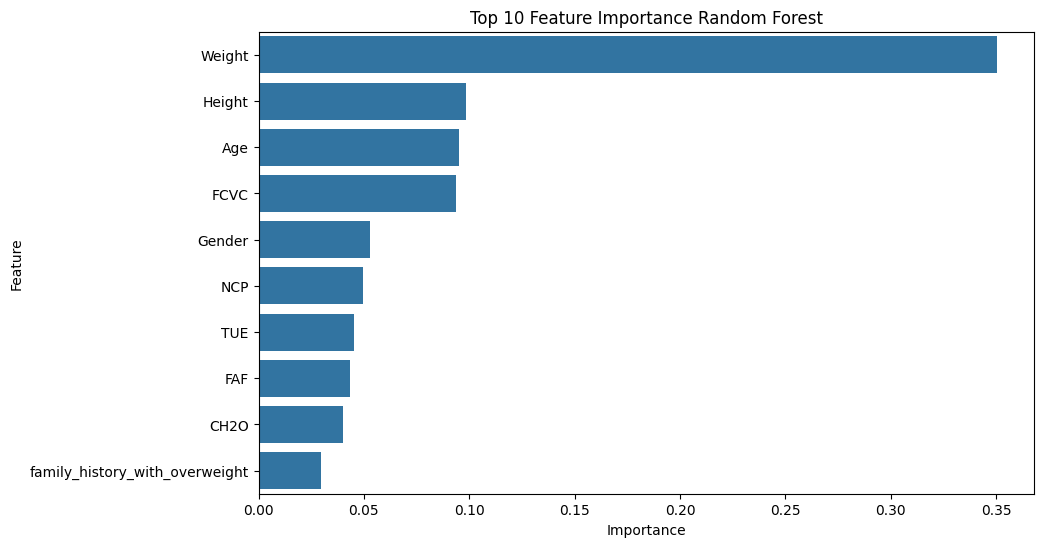

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_rf.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance Random Forest')

plt.show()

## **Evaluasi Model**

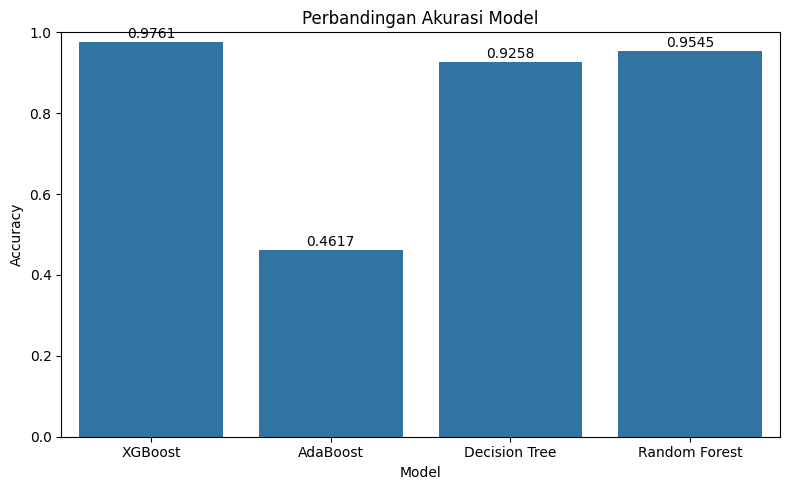

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score

# =========================
# 1. Perbandingan Akurasi Model
# =========================
model_results = pd.DataFrame({
    'Model': ['XGBoost', 'AdaBoost', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

plt.figure(figsize=(8,5))
sns.barplot(data=model_results, x='Model', y='Accuracy')
plt.title('Perbandingan Akurasi Model')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xlabel('Model')

for i, value in enumerate(model_results['Accuracy']):
    plt.text(i, value + 0.01, f'{value:.4f}', ha='center')

plt.tight_layout()
plt.show()

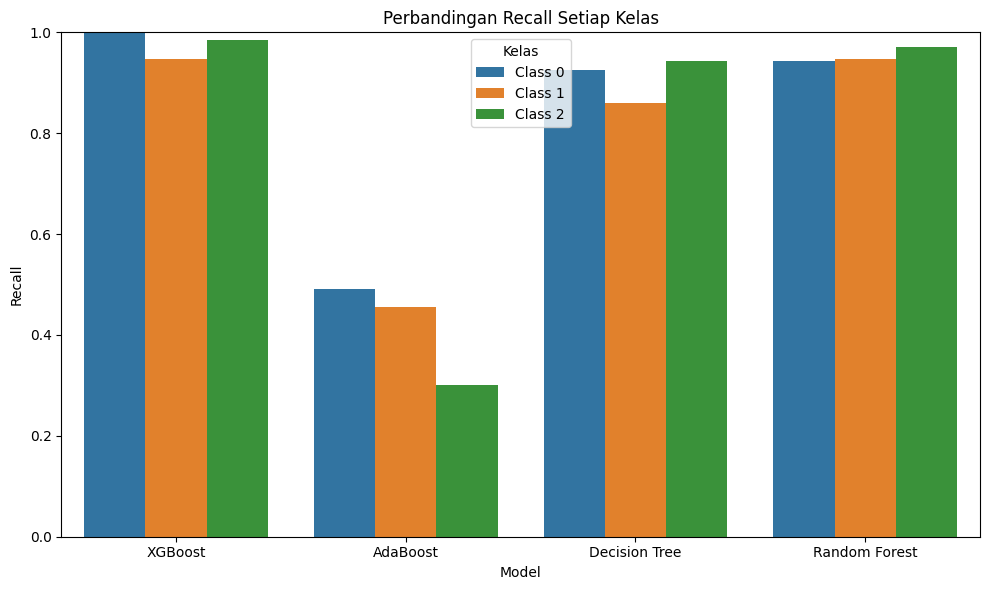

In [64]:
# =========================
# 2. Kemampuan Model Mendeteksi Setiap Kelas
# pakai Recall per kelas 0,1,2
# =========================
recall_results = pd.DataFrame({
    'Model': ['XGBoost', 'AdaBoost', 'Decision Tree', 'Random Forest'],
    'Class 0': [
        recall_score(y_test, y_pred, average=None)[0],
        recall_score(y_test, y_pred_ada, average=None)[0],
        recall_score(y_test, y_pred_dt, average=None)[0],
        recall_score(y_test, y_pred_rf, average=None)[0]
    ],
    'Class 1': [
        recall_score(y_test, y_pred, average=None)[1],
        recall_score(y_test, y_pred_ada, average=None)[1],
        recall_score(y_test, y_pred_dt, average=None)[1],
        recall_score(y_test, y_pred_rf, average=None)[1]
    ],
    'Class 2': [
        recall_score(y_test, y_pred, average=None)[2],
        recall_score(y_test, y_pred_ada, average=None)[2],
        recall_score(y_test, y_pred_dt, average=None)[2],
        recall_score(y_test, y_pred_rf, average=None)[2]
    ]
})

recall_melted = recall_results.melt(
    id_vars='Model',
    var_name='Class',
    value_name='Recall'
)

plt.figure(figsize=(10,6))
sns.barplot(data=recall_melted, x='Model', y='Recall', hue='Class')

plt.title('Perbandingan Recall Setiap Kelas')
plt.ylim(0, 1)
plt.ylabel('Recall')
plt.xlabel('Model')
plt.legend(title='Kelas')

plt.tight_layout()
plt.show()

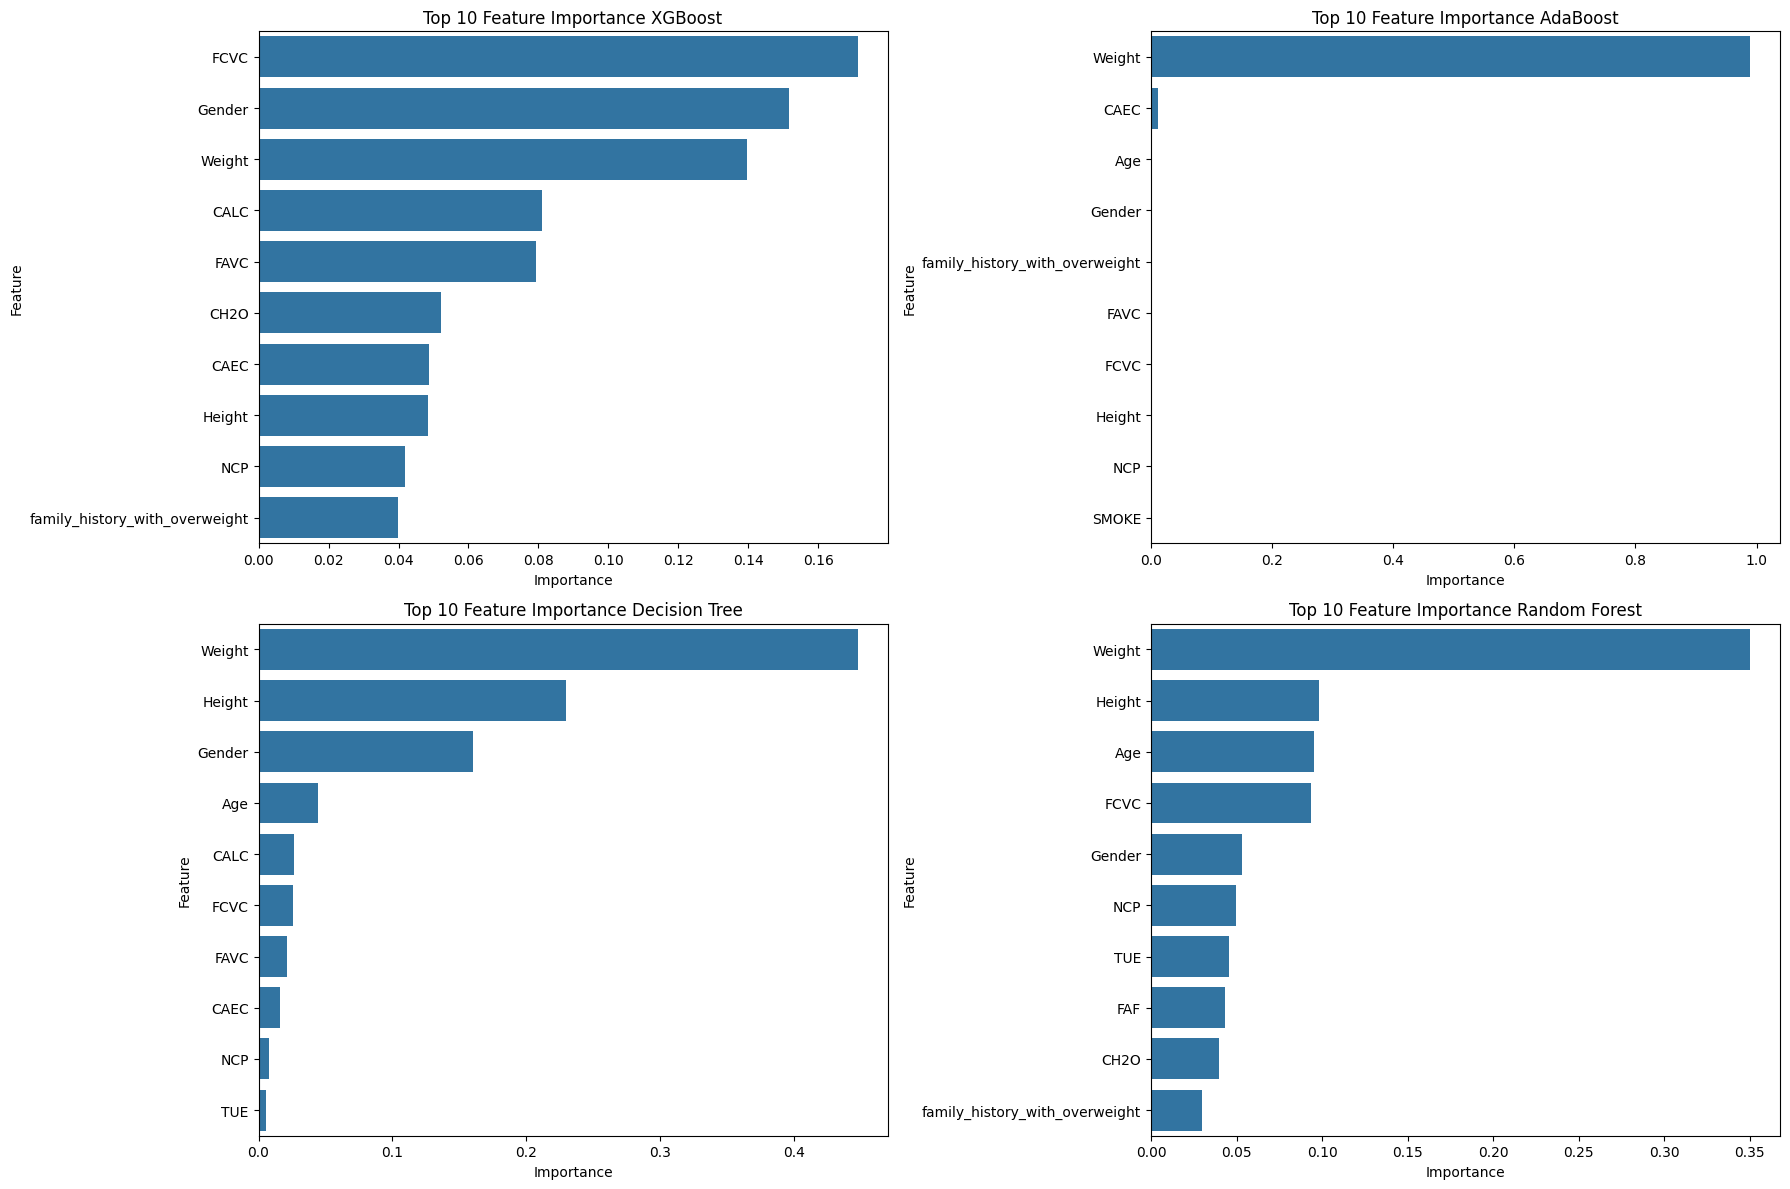

In [65]:
# =========================
# 3. Feature Importance 4 Model dalam 1 Frame
# =========================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

feature_data = [
    (feature_importance, 'XGBoost'),
    (feature_importance_ada, 'AdaBoost'),
    (feature_importance_dt, 'Decision Tree'),
    (feature_importance_rf, 'Random Forest')
]

for ax, (data, title) in zip(axes.flatten(), feature_data):
    top_features = data.head(10)

    sns.barplot(
        data=top_features,
        x='Importance',
        y='Feature',
        ax=ax
    )

    ax.set_title(f'Top 10 Feature Importance {title}')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

In [66]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Base model AdaBoost
ada = AdaBoostClassifier(
    random_state=42
)

# Parameter yang mau dicoba
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1],
    'estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=42),
        DecisionTreeClassifier(max_depth=2, random_state=42),
        DecisionTreeClassifier(max_depth=3, random_state=42)
    ]
}

# Grid Search
grid_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

# Best parameter
print("Best Parameters:", grid_ada.best_params_)
print("Best CV Accuracy:", grid_ada.best_score_)

# Model terbaik
best_ada = grid_ada.best_estimator_

# Prediksi
y_pred_ada_tuned = best_ada.predict(X_test)

# Evaluasi
print("Test Accuracy:", accuracy_score(y_test, y_pred_ada_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada_tuned))

Best Parameters: {'estimator': DecisionTreeClassifier(max_depth=3, random_state=42), 'learning_rate': 0.5, 'n_estimators': 300}
Best CV Accuracy: 0.9442862023700347
Test Accuracy: 0.9473684210526315

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.96      0.89      0.93        57
           2       0.97      0.91      0.94        70
           3       0.97      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.88      0.93      0.90        55
           6       0.87      0.95      0.91        58

    accuracy                           0.95       418
   macro avg       0.95      0.95      0.95       418
weighted avg       0.95      0.95      0.95       418


Confusion Matrix:
[[52  1  0  0  0  0  0]
 [ 1 51  0  0  0  5  0]
 [ 0  0 64  1  0  0  5]
 [ 0  0  1 59  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  1  0  0  0 51  3]
 [ 0  0  1  0  0 